In [1]:
import utils as ut
import pandas as pd

# Validation

#### W tuning results and performance relative to benchmarks

In [ ]:
static_benchmarks = pd.read_parquet(f'{ut.results_dir}/benchmarks/ll_only/')
ll_tuning_run = pd.read_parquet(f'{ut.results_dir}/LL_runner/ll_only/')

ll_tuning_run['model_name'] = ll_tuning_run['hurdle_model'].map({True: 'LL_hurdle', False: 'LL_NB'})
ll_tuning_run = ll_tuning_run[['w_inf', 'model_name', 'test_valid', 'non_degen_ll', 'run_timestamp']]
static_benchmarks['w_inf'] = 0

results = pd.concat([ll_tuning_run, static_benchmarks])
results.sort_values(by='non_degen_ll', ascending=False).head()

In [ ]:
results = results.reset_index(drop=True)
results.sort_values('non_degen_ll', ascending=False).drop_duplicates('model_name')

#### Cluster Smoothing validaiton performance

In [ ]:
cluster_smoothing = pd.read_parquet(f'{ut.results_dir}/cluster_smoothing/ll_only/')
cluster_smoothing.sort_values(by='non_degen_ll', ascending=False).head(10)

#### Global Smoothing Validation performance

In [ ]:
global_smoothing = pd.read_parquet(f'{ut.results_dir}/global_smoothing/ll_only/')
global_smoothing.sort_values(by='non_degen_ll', ascending=False).head(10)

# Test

In [1]:
import l_result_preperation as l
import matplotlib.pyplot as plt
import numpy as np 
import utils as ut
import os 
import m_plots as m
import seaborn as sns

outputs_dir = f'{ut.project_root}/outputs'
os.makedirs(outputs_dir, exist_ok=True)

In [2]:
# Loading in test results and concat together
runtime_configs = ut.load_json5('runtime_configs')
ll_calibration_results, ll_user_results, benchmark_results = l.load_test_results(results_dir=ut.results_dir, n_test_seeds=runtime_configs['n_test_seeds'])

##### Processing Data

In [ ]:
activity_decile = l.get_activity_decile_improvement(ll_calibration_results=ll_calibration_results)
user_pct_ll_improvement = l.get_user_pct_ll_improvement(ll_user_results=ll_user_results)

calibration = l.get_calibration_summary(ll_calibration_results=ll_calibration_results)
attack_detection = l.get_attack_detection_summary(results_dir=ut.results_dir, n_test_seeds=runtime_configs['n_test_seeds'])
attack_threshold_differences = l.get_mean_threshold_differences(detection_results=attack_detection)

##### Activity decile plot

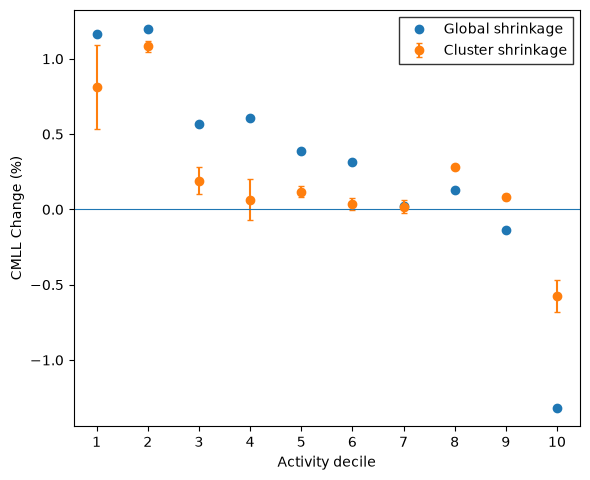

In [4]:
fig, ax = m.declile_log_likelihood_plot(decile_results=activity_decile, x_label='Activity decile', error_bars=True)
fig.savefig(f'{outputs_dir}/activity_decile_relative.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()

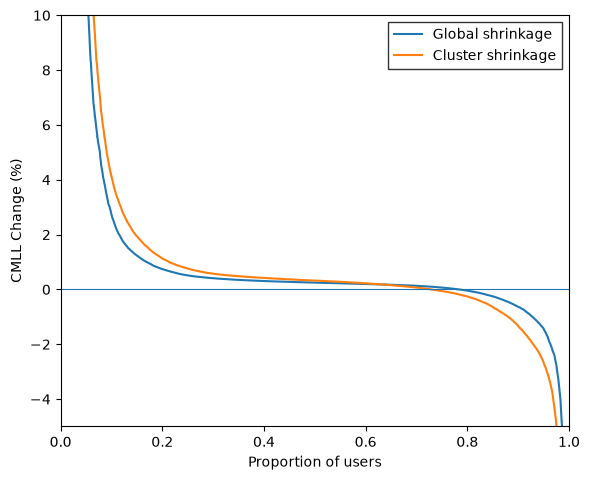

In [5]:
fig, ax = m.plot_user_pct_ll_improvemet(user_improvements=user_pct_ll_improvement)
fig.savefig(f'{outputs_dir}/user_pct_ll_improvement.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()

##### Calibration plot

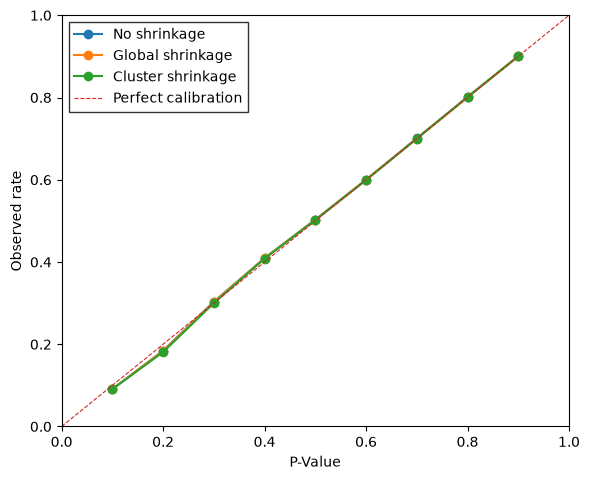

In [6]:
fig, ax = m.plot_calibration(calibration_df=calibration, extreme=False, error_bars=False)
fig.savefig(f'{outputs_dir}/decile_calibration.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()

##### Extreme Calibration Table + plot

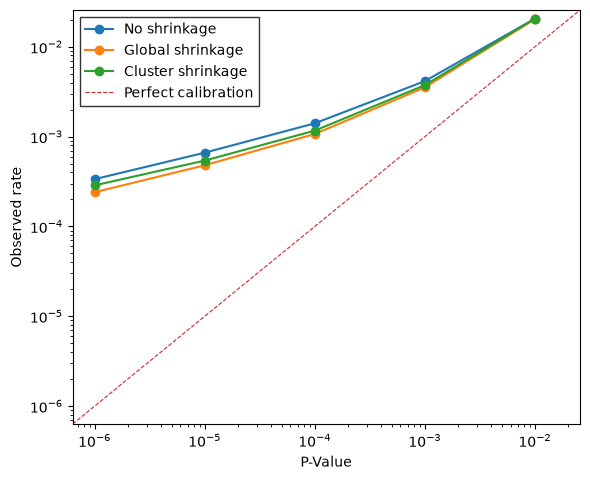

In [7]:
fig, ax = m.plot_calibration(calibration_df=calibration, extreme=True, error_bars=False)
fig.savefig(f'{outputs_dir}/extreme_calibration.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()

##### Overall Comparison Table

In [ ]:
overall_performance_output = m.get_overall_performance_output(ll_calibration_results, benchmark_results)
overall_performance_output.to_csv(f'{outputs_dir}/overall_performance.csv', index=False)
overall_performance_output

,Model,Overall CMLL,$\Delta$ CMLL,Human CMLL,Machine CMLL
0,Cluster shrinkage,-1.3740 \n $\pm$ 0.0003,0.0004 \n $\pm$ 0.0003,-1.0157 \n $\pm$ 0.0007,-1.6143 \n $\pm$ 0.0003
1,No shrinkage,-1.3744,-,-1.0085,-1.6198
2,Global shrinkage,-1.3750,-0.0006,-1.0126,-1.6181
3,Hourly user benchmark,-1.4520,-0.0776,-1.0545,-1.7186
4,User level benchmark,-1.4557,-0.0813,-1.0477,-1.7293


#### Attack Detection Plot

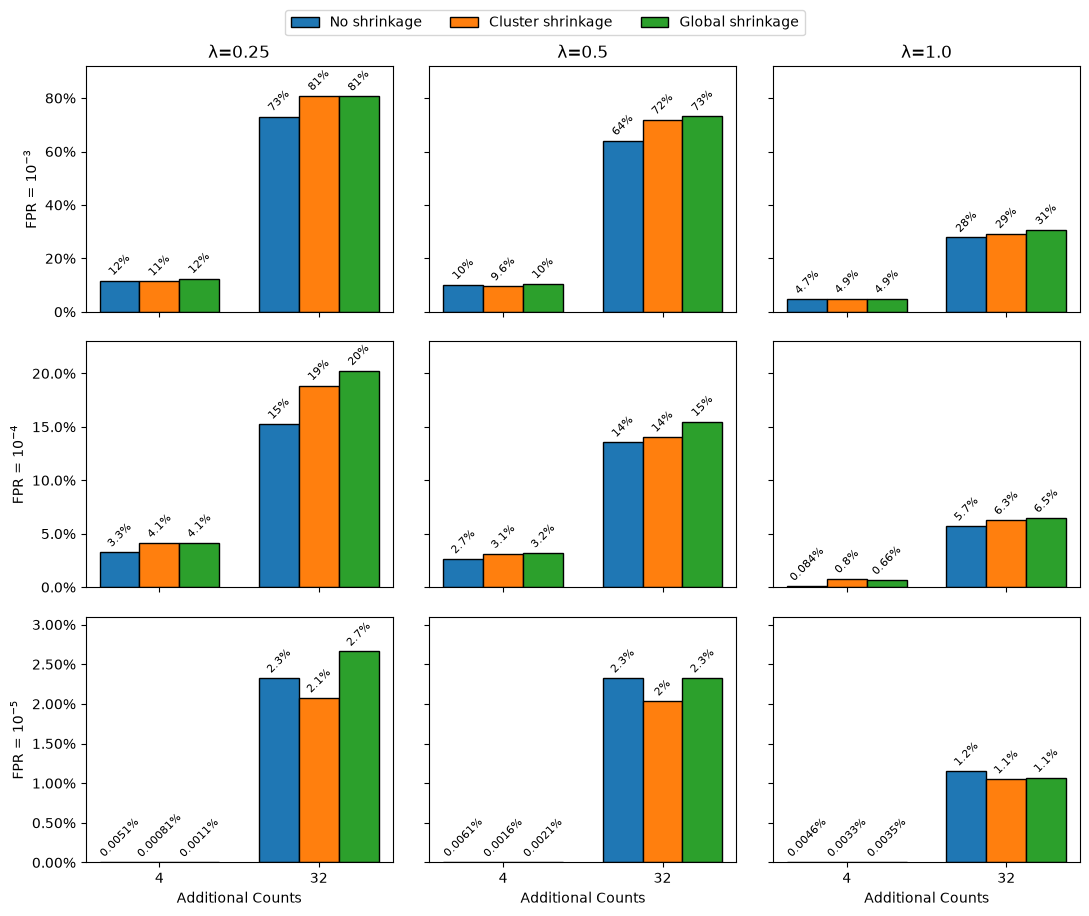

In [9]:
fig, axes = m.plot_small_attack_detection(detection_results=attack_detection, runtime_configs=runtime_configs)
fig.savefig(f'{outputs_dir}/attack_detection_small.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()

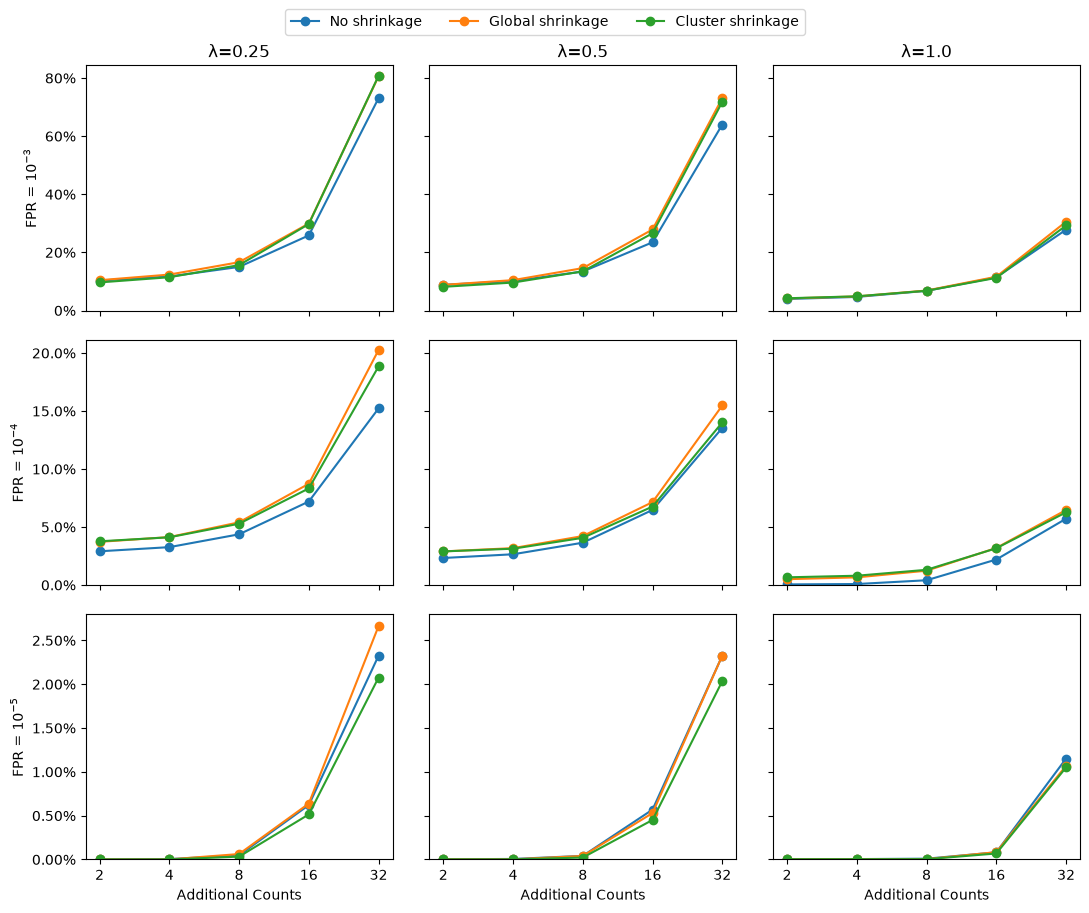

In [10]:
fig, axes = m.plot_full_attack_detection(detection_results=attack_detection, runtime_configs=runtime_configs, error_bars=False)
fig.savefig(f'{outputs_dir}/attack_detection_full.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()

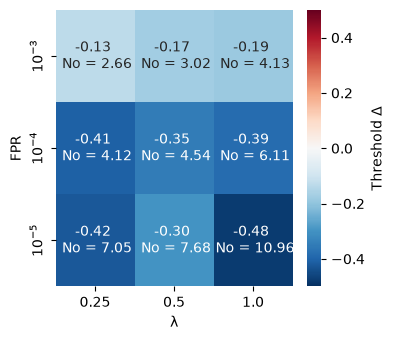

In [11]:
fig, axes = m.plot_threshold_heatmap(threshold_differences=attack_threshold_differences, model='global_smoothing')
fig.savefig(f'{outputs_dir}/gs_attack_threshold_differences.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()

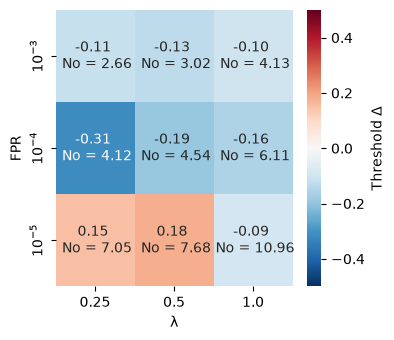

In [12]:
fig, axes = m.plot_threshold_heatmap(threshold_differences=attack_threshold_differences, model='cluster_smoothing')
fig.savefig(f'{outputs_dir}/cs_attack_threshold_differences.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()